# Mataquito River – Quartz & Zircon Fertility Analysis

Monte Carlo error propagation using flux-ordered erosion rates and detritalPy-mix bootstrap mixing coefficients.

**Sample convention:**
- CT-5 and CT-8 are always **sample A** (numerator)
- CT-6 and CT-3 are always **sample B** (denominator)
- All ratios reported as **Qa/Qb** and **ZA/ZB**

**Erosion rate uncertainty:** External uncertainty used throughout (includes production rate uncertainty).

**Sections:**
1. Imports
2. Load sample data
3. Monte Carlo erosion rate samples
4. Flux ordering
5. Flux-ordered erosion rate plots
6. Fertility functions
7. Load zircon mixing coefficients
8. Mixing coefficient violin plots
9. Quartz fertility
10. Zircon fertility
11. Quartz fertility violin plots
12. Zircon fertility violin plots
13. Distribution plots (individual + combined)
14. Results summary

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv, os

os.makedirs('Figures', exist_ok=True)

N = 100_000  # Number of Monte Carlo samples for erosion rate distributions

## 2. Load sample data

In [2]:
# Load sample data from Excel file
# Row index: CT-1=0, CT-2=1, CT-3=2, CT-4=3, CT-5=4, CT-6=5,
#            CT-7=6, CT-8=7, CT-9=8, CT-10=9, CT-11=10
df = pd.read_excel('/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/MataquitoSampleData.xlsx')

print(df[['Sample_ID','Source_Area','Erosion_rate',
          'Erosion_rate_uncertainty_internal',
          'Erosion_rate_uncertainty_external',
          'Surface_Production_Rate']])

# Build lookup dictionaries for source area and production rate by sample ID
A = df.set_index('Sample_ID')['Source_Area'].to_dict()            # km²
P = df.set_index('Sample_ID')['Surface_Production_Rate'].to_dict()  # at/g/yr

   Sample_ID  Source_Area  Erosion_rate  Erosion_rate_uncertainty_internal  \
0       CT-1     1385.185          22.9                              0.281   
1       CT-2     5760.128          94.8                              1.810   
2       CT-3      189.205          29.5                              0.556   
3       CT-4     4706.717          29.6                              0.594   
4       CT-5     1495.897         387.0                              9.230   
5       CT-6     2573.245          29.8                              0.566   
6       CT-7     1207.810         532.0                             30.600   
7       CT-8     4950.395         263.0                              9.650   
8       CT-9     6189.716         105.0                              2.010   
9      CT-10     4864.942         246.0                              8.660   
10     CT-11     4913.334         286.0                              9.560   

    Erosion_rate_uncertainty_external  Surface_Production_Rate 

## 3. Monte Carlo erosion rate samples

Erosion rates are normally distributed with mean = measured rate and sigma = external uncertainty.
External uncertainty includes production rate uncertainty and is the more conservative estimate.

In [3]:
np.random.seed(17)

# Generate N random erosion rate samples per site using external uncertainty
ER_ext = {}
for i, row in df.iterrows():
    sid = row['Sample_ID']
    ER_ext[sid] = np.random.normal(
        row['Erosion_rate'],                       # mean: measured erosion rate (m/Myr)
        row['Erosion_rate_uncertainty_external'],   # sigma: external uncertainty
        N
    )

print(f"{'Sample':<8} {'Median (m/Myr)':>15} {'Std':>8}")
print("-"*35)
for sid in df['Sample_ID']:
    print(f"{sid:<8} {np.median(ER_ext[sid]):>15.2f} {np.std(ER_ext[sid]):>8.2f}")

Sample    Median (m/Myr)      Std
-----------------------------------
CT-1               22.90     1.86
CT-2               94.83     7.72
CT-3               29.50     2.41
CT-4               29.61     2.44
CT-5              387.02    31.89
CT-6               29.80     2.44
CT-7              532.06    51.92
CT-8              262.93    22.85
CT-9              105.00     8.56
CT-10             245.84    21.31
CT-11             286.06    24.57


## 4. Flux ordering

Physical constraint: downstream sediment flux (E × A) must be ≥ upstream flux.
Samples violating this are discarded; filtered distributions resampled with replacement back to N.

**Ordering chain:**
- CT-7 → CT-5
- CT-1 → CT-6
- CT-5 + CT-6 → CT-10 / CT-11 / CT-8
- CT-4 → CT-8 (for CT-8 parent scenarios)
- CT-3 is hydrologically independent

In [4]:
np.random.seed(17)

# ── CT-7 → CT-5 ──────────────────────────────────────────────────────────────
m_75 = np.where(ER_ext['CT-5'] * A['CT-5'] > ER_ext['CT-7'] * A['CT-7'])[0]
CT5_ord = ER_ext['CT-5'][m_75]
CT7_ord = ER_ext['CT-7'][m_75]  # store for plotting
print(f"CT-7→CT-5:        {len(m_75):>6}/{N} ({100*len(m_75)/N:.1f}%) retained")

# ── CT-1 → CT-6 ──────────────────────────────────────────────────────────────
m_16 = np.where(ER_ext['CT-6'] * A['CT-6'] > ER_ext['CT-1'] * A['CT-1'])[0]
CT6_ord = ER_ext['CT-6'][m_16]
CT1_ord = ER_ext['CT-1'][m_16]  # store for plotting
print(f"CT-1→CT-6:        {len(m_16):>6}/{N} ({100*len(m_16)/N:.1f}%) retained")

# Resample back to N with replacement
CT5_res = np.random.choice(CT5_ord, size=N, replace=True)
CT6_res = np.random.choice(CT6_ord, size=N, replace=True)

# ── CT-5 + CT-6 → CT-10 ──────────────────────────────────────────────────────
m_10 = np.where(ER_ext['CT-10'] * A['CT-10'] >= CT5_res * A['CT-5'] + CT6_res * A['CT-6'])[0]
CT5_10 = CT5_res[m_10]; CT6_10 = CT6_res[m_10]; CT10_f = ER_ext['CT-10'][m_10]
print(f"CT-5+CT-6→CT-10:  {len(m_10):>6}/{N} ({100*len(m_10)/N:.1f}%) retained")

# ── CT-5 + CT-6 → CT-11 ──────────────────────────────────────────────────────
m_11 = np.where(ER_ext['CT-11'] * A['CT-11'] >= CT5_res * A['CT-5'] + CT6_res * A['CT-6'])[0]
CT5_11 = CT5_res[m_11]; CT6_11 = CT6_res[m_11]; CT11_f = ER_ext['CT-11'][m_11]
print(f"CT-5+CT-6→CT-11:  {len(m_11):>6}/{N} ({100*len(m_11)/N:.1f}%) retained")

# ── CT-5 + CT-6 → CT-8 ───────────────────────────────────────────────────────
m_8 = np.where(ER_ext['CT-8'] * A['CT-8'] >= CT5_res * A['CT-5'] + CT6_res * A['CT-6'])[0]
CT5_8 = CT5_res[m_8]; CT6_8 = CT6_res[m_8]; CT8_f = ER_ext['CT-8'][m_8]
print(f"CT-5+CT-6→CT-8:   {len(m_8):>6}/{N} ({100*len(m_8)/N:.1f}%) retained")

# ── CT-4 → CT-8 (CT-8 as parent) ─────────────────────────────────────────────
m_48 = np.where(ER_ext['CT-8'] * A['CT-8'] > ER_ext['CT-4'] * A['CT-4'])[0]
CT4_48 = ER_ext['CT-4'][m_48]  # store for plotting
CT8_48 = ER_ext['CT-8'][m_48]  # store for plotting
CT8_res = np.random.choice(CT8_48, size=N, replace=True)
print(f"CT-4→CT-8:        {len(m_48):>6}/{N} ({100*len(m_48)/N:.1f}%) retained")

# ── Independent resamples ─────────────────────────────────────────────────────
CT3_res  = np.random.choice(ER_ext['CT-3'],  size=N, replace=True)  # CT-3 independent
CT4_res  = np.random.choice(ER_ext['CT-4'],  size=N, replace=True)
CT10_res = np.random.choice(CT10_f,          size=N, replace=True)
CT11_res = np.random.choice(CT11_f,          size=N, replace=True)

CT-7→CT-5:         20997/100000 (21.0%) retained
CT-1→CT-6:        100000/100000 (100.0%) retained
CT-5+CT-6→CT-10:  100000/100000 (100.0%) retained
CT-5+CT-6→CT-11:  100000/100000 (100.0%) retained
CT-5+CT-6→CT-8:   100000/100000 (100.0%) retained
CT-4→CT-8:        100000/100000 (100.0%) retained


## 5. Flux-ordered erosion rate plots

KDE plots showing before/after flux ordering for each constrained pair.
Dashed = unordered (raw Monte Carlo), solid = flux-ordered.

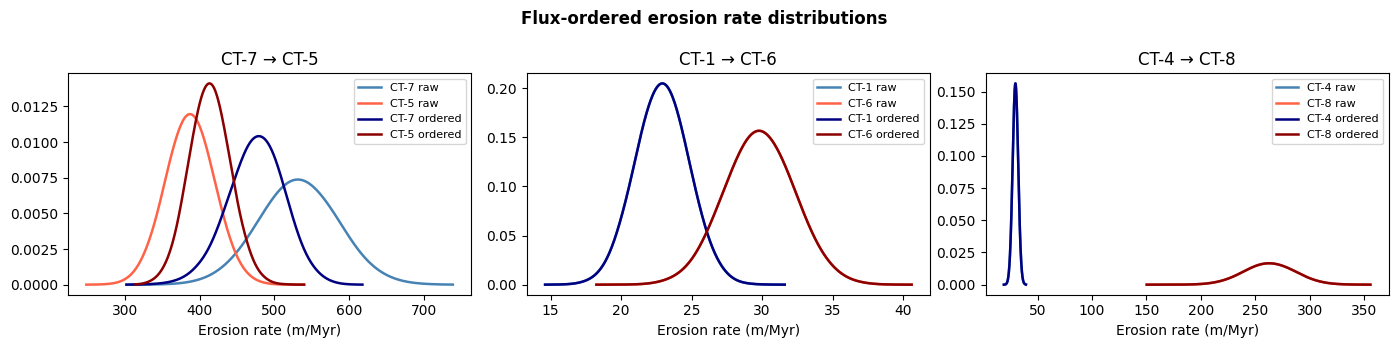

In [5]:
from scipy.stats import gaussian_kde

def kde_plot(ax, samples_list, labels, colors, title, xlabel='Erosion rate (m/Myr)'):
    """
    Overlay KDE curves for multiple sample arrays on one axis.
    samples_list: list of 1D arrays
    labels, colors: matched lists
    """
    for arr, lbl, col in zip(samples_list, labels, colors):
        kde = gaussian_kde(arr, bw_method=0.3)
        x = np.linspace(arr.min(), arr.max(), 500)
        ax.plot(x, kde(x), label=lbl, color=col, linewidth=1.8)
    ax.set_xlabel(xlabel); ax.set_title(title)
    ax.legend(fontsize=8)
    #ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── Panel 1: CT-7 / CT-5 ordering ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
fig.suptitle('Flux-ordered erosion rate distributions', fontsize=12, fontweight='bold')

kde_plot(axes[0],
    [ER_ext['CT-7'], ER_ext['CT-5'], CT7_ord, CT5_ord],
    ['CT-7 raw','CT-5 raw','CT-7 ordered','CT-5 ordered'],
    ['steelblue','tomato','navy','darkred'],
    'CT-7 → CT-5')

# ── Panel 2: CT-1 / CT-6 ordering ────────────────────────────────────────────
kde_plot(axes[1],
    [ER_ext['CT-1'], ER_ext['CT-6'], CT1_ord, CT6_ord],
    ['CT-1 raw','CT-6 raw','CT-1 ordered','CT-6 ordered'],
    ['steelblue','tomato','navy','darkred'],
    'CT-1 → CT-6')

# ── Panel 3: CT-4 / CT-8 ordering ────────────────────────────────────────────
kde_plot(axes[2],
    [ER_ext['CT-4'], ER_ext['CT-8'], CT4_48, CT8_48],
    ['CT-4 raw','CT-8 raw','CT-4 ordered','CT-8 ordered'],
    ['steelblue','tomato','navy','darkred'],
    'CT-4 → CT-8')

plt.tight_layout()
plt.savefig('Figures/erosion_rates_ordered_pairs.png', dpi=300, bbox_inches='tight')
plt.show()

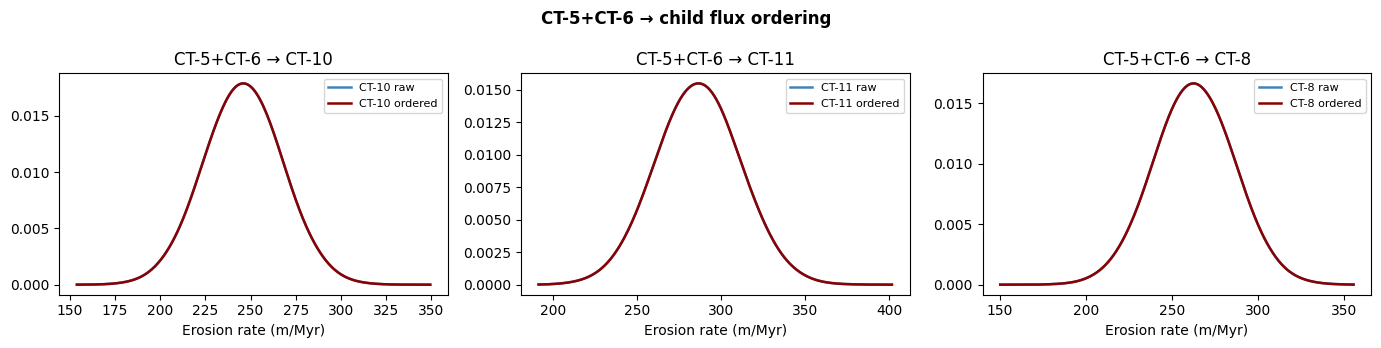

In [6]:
# ── CT-5+CT-6 → child sample ordering ────────────────────────────────────────
# Show how child sample distributions change after applying combined upstream flux constraint
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
fig.suptitle('CT-5+CT-6 → child flux ordering', fontsize=12, fontweight='bold')

for ax, ct_raw, ct_f, label in zip(
    axes,
    [ER_ext['CT-10'], ER_ext['CT-11'], ER_ext['CT-8']],
    [CT10_f, CT11_f, CT8_f],
    ['CT-10', 'CT-11', 'CT-8']
):
    kde_plot(ax,
        [ct_raw, ct_f],
        [f'{label} raw', f'{label} ordered'],
        ['steelblue', 'darkred'],
        f'CT-5+CT-6 → {label}')

plt.tight_layout()
plt.savefig('Figures/erosion_rates_child_ordering.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# ── Summary table of all flux-ordered erosion rates ──────────────────────────
print(f"{'Array':<32} {'Median (m/Myr)':>15} {'Std':>8}")
print("-"*58)
for label, arr in [
    ('CT-1 (raw)',                 ER_ext['CT-1']),
    ('CT-2 (raw)',                 ER_ext['CT-2']),
    ('CT-3 (independent)',         CT3_res),
    ('CT-4 (raw)',                 ER_ext['CT-4']),
    ('CT-5 (ordered vs CT-7)',     CT5_res),
    ('CT-6 (ordered vs CT-1)',     CT6_res),
    ('CT-7 (raw)',                 ER_ext['CT-7']),
    ('CT-8 (ordered vs CT-4)',     CT8_res),
    ('CT-9 (raw)',                 ER_ext['CT-9']),
    ('CT-10 (ordered vs CT-5+6)',  CT10_f),
    ('CT-11 (ordered vs CT-5+6)',  CT11_f),
    ('CT-5 | CT-10 scenario',      CT5_10),
    ('CT-6 | CT-10 scenario',      CT6_10),
    ('CT-5 | CT-11 scenario',      CT5_11),
    ('CT-6 | CT-11 scenario',      CT6_11),
    ('CT-5 | CT-8 scenario',       CT5_8),
    ('CT-6 | CT-8 scenario',       CT6_8),
    ('CT-8 (via CT-5+CT-6)',       CT8_f),
]:
    print(f"{label:<32} {np.median(arr):>15.2f} {np.std(arr):>8.2f}")

Array                             Median (m/Myr)      Std
----------------------------------------------------------
CT-1 (raw)                                 22.90     1.86
CT-2 (raw)                                 94.83     7.72
CT-3 (independent)                         29.50     2.41
CT-4 (raw)                                 29.61     2.44
CT-5 (ordered vs CT-7)                    413.27    27.18
CT-6 (ordered vs CT-1)                     29.79     2.43
CT-7 (raw)                                532.06    51.92
CT-8 (ordered vs CT-4)                    262.91    22.87
CT-9 (raw)                                105.00     8.56
CT-10 (ordered vs CT-5+6)                 245.84    21.31
CT-11 (ordered vs CT-5+6)                 286.06    24.57
CT-5 | CT-10 scenario                     413.27    27.18
CT-6 | CT-10 scenario                      29.79     2.43
CT-5 | CT-11 scenario                     413.27    27.18
CT-6 | CT-11 scenario                      29.79     2.43
CT-5 | CT-8 s

## 6. Fertility functions

In [8]:
THRESHOLD = 0.01  # Filter mixing coefficients below 1% or above 99%

def load_wct(csv_path):
    """
    Load two-column detritalPy-mix bootstrap coefficient CSV.
    Filters rows where either coefficient is outside (0.01, 0.99) to avoid
    near-zero denominator instability in ratio calculations.

    Returns: wa (array), wb (array), n_total (int), n_kept (int)
    """
    wa, wb = [], []
    n = 0
    with open(csv_path) as f:
        reader = csv.reader(f)
        next(reader)  # skip header
        for row in reader:
            n += 1
            a, b = float(row[0]), float(row[1])
            # Keep only rows where both coefficients are in open interval (0.01, 0.99)
            if a > THRESHOLD and a < (1 - THRESHOLD) and b > THRESHOLD and b < (1 - THRESHOLD):
                wa.append(a)
                wb.append(b)
    return np.array(wa), np.array(wb), n, len(wa)


def quartz_fertility(E_a, E_b, E_c, A_a, A_b, A_c, P_a, P_b, P_c):
    """
    Compute quartz fertility ratio Qa/Qb from the sediment mixing equation.

    Equation: Qb/Qa = (Pc*Ea*Aa - Pa*Ec*Aa) / (Pb*Ec*Ab - Pc*Eb*Ab)
    Qa/Qb returned as inverse. Only positive samples retained.

    E_a, E_b, E_c : erosion rate sample arrays (m/Myr)
    A_a, A_b, A_c : source areas (km²) — scalars
    P_a, P_b, P_c : spallation production rates (at/g/yr) — scalars

    Returns: Qa_Qb array (positive values only), boolean mask
    """
    num = P_c * E_a * A_a - P_a * E_c * A_a  # numerator of Qb/Qa
    den = P_b * E_c * A_b - P_c * E_b * A_b  # denominator of Qb/Qa
    Qb_Qa = num / den
    mask = Qb_Qa > 0  # retain only physically meaningful positive values
    return (1 / Qb_Qa[mask]), mask  # return Qa/Qb


def zircon_fertility(wa, wb, ER_A, ER_B, A_A, A_B, num_samples=10000, seed=17):
    """
    Compute zircon fertility ratio ZA/ZB using Equation 11.

    Equation: ZA/ZB = (wct_a/wct_b) * (ER_B * A_B) / (ER_A * A_A)

    wct rows sampled by coupled index to preserve wct_a + wct_b = 1.
    Erosion rate samples taken as first num_samples elements of input arrays.

    wa, wb       : coupled bootstrap mixing coefficient arrays from detritalPy-mix
    ER_A, ER_B   : flux-ordered erosion rate arrays (m/Myr)
    A_A, A_B     : source areas (km²) — scalars
    num_samples  : number of Monte Carlo draws
    seed         : random seed for reproducibility

    Returns: dict with ZA_ZB and ZB_ZA sub-dicts, each containing
             samples, median, p25, p75, and log10 equivalents
    """
    np.random.seed(seed)

    # Sample row indices keeping wct_a and wct_b coupled (preserves wct_a + wct_b = 1)
    idx = np.random.choice(len(wa), size=num_samples, replace=True)
    ratio = wa[idx] / wb[idx]  # wct_a / wct_b for each sampled bootstrap row

    ER_A_s = ER_A[:num_samples]  # first num_samples from flux-ordered array
    ER_B_s = ER_B[:num_samples]

    # Eq. 11: ZA/ZB = (wct_a/wct_b) * (ER_B * A_B) / (ER_A * A_A)
    ZA_ZB = ratio * (ER_B_s * A_B) / (ER_A_s * A_A)

    def stats(x):
        """Summary statistics for a 1D distribution including log10 equivalents."""
        return {
            'samples':       x,
            'median':        np.median(x),
            'p25':           np.percentile(x, 25),
            'p75':           np.percentile(x, 75),
            'log10_samples': np.log10(x),
            'log10_median':  np.median(np.log10(x)),
            'log10_p25':     np.percentile(np.log10(x), 25),
            'log10_p75':     np.percentile(np.log10(x), 75),
        }

    return {'ZA_ZB': stats(ZA_ZB), 'ZB_ZA': stats(1 / ZA_ZB)}

print("Functions loaded.")

Functions loaded.


## 7. Load zircon mixing coefficients

In [9]:
BASE = '/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/Zircon/detritalPy_mix/Spreadsheets/'

# Map scenario keys to CSV filenames
csv_paths = {
    'ct4':     'mix_coeffs_all_ct-5_ct-6_to_ct-4.csv',
    'ct10':    'mix_coeffs_all_ct-5_ct-6_to_ct-10.csv',
    'ct11':    'mix_coeffs_all_ct-5_ct-6_to_ct-11.csv',
    'ct82':    'mix_coeffs_all_ct-5_ct-6_to_ct-8.2.csv',
    'ct9_83':  'mix_coeffs_all_ct-8.2_ct-3_to_ct-9.csv',
    'ct2_83':  'mix_coeffs_all_ct-8.2_ct-3_to_ct-2.csv',
    'ct9_43':  'mix_coeffs_all_ct-4_ct-3_to_ct-9.csv',
    'ct9_103': 'mix_coeffs_all_ct-10_ct-3_to_ct-9.csv',
    'ct9_113': 'mix_coeffs_all_ct-11_ct-3_to_ct-9.csv',
}

# Load and filter all CSVs, print retention summary
wct = {}
print(f"{'Key':<12} {'Kept':>6} {'Total':>7} {'% kept':>7} {'Med wct_a':>10} {'Med wct_b':>10}")
print("-"*57)
for key, fname in csv_paths.items():
    wa, wb, nt, nk = load_wct(BASE + fname)
    wct[key] = (wa, wb)
    print(f"{key:<12} {nk:>6} {nt:>7} {100*nk/nt:>6.1f}% {np.median(wa):>10.4f} {np.median(wb):>10.4f}")

Key            Kept   Total  % kept  Med wct_a  Med wct_b
---------------------------------------------------------
ct4            9886   10000   98.9%     0.2675     0.7325
ct10           9999   10000  100.0%     0.6398     0.3602
ct11           9991   10000   99.9%     0.4618     0.5382
ct82          10000   10000  100.0%     0.5225     0.4775
ct9_83         9983   10000   99.8%     0.8666     0.1334
ct2_83         9998   10000  100.0%     0.8260     0.1740
ct9_43         8821   10000   88.2%     0.9365     0.0635
ct9_103        9998   10000  100.0%     0.8683     0.1317
ct9_113        9994   10000   99.9%     0.8876     0.1124


## 8. Mixing coefficient violin plots

Horizontal violin plots of bootstrap wct distributions for each scenario.
Shows the spread of parent mixing proportions from detritalPy-mix iterations.

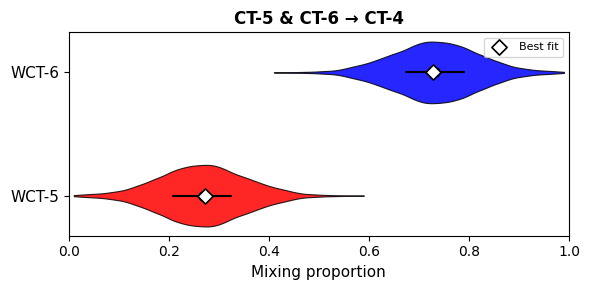

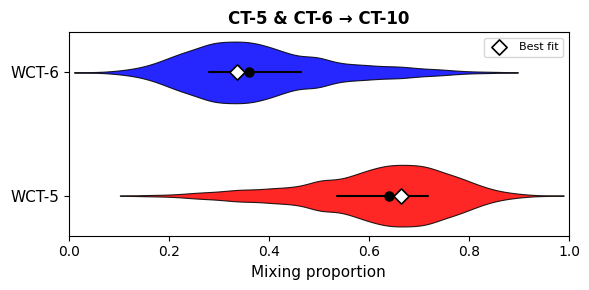

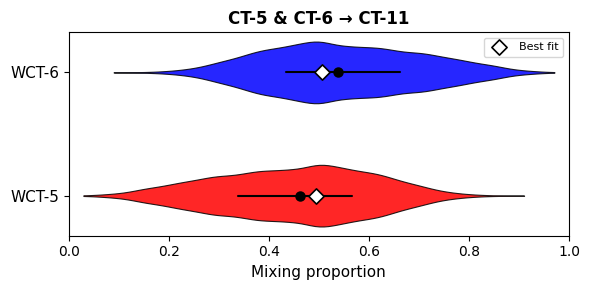

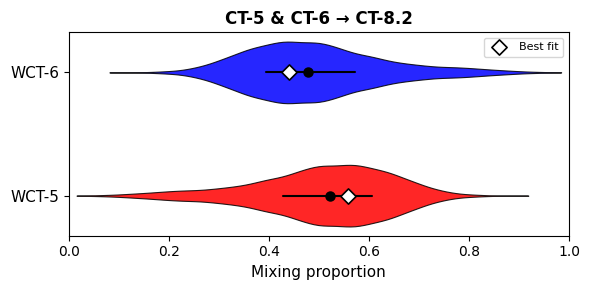

In [10]:
def plot_wct_violin(wa, wb, labels, title, best_fit=None, save_path=None, figsize=(6, 3)):
    """
    Horizontal violin plot for two-component mixing coefficients.

    wa, wb      : filtered bootstrap coefficient arrays
    labels      : [label_a, label_b] for y-axis
    best_fit    : optional [val_a, val_b] to overlay as white dots
    """
    fig, ax = plt.subplots(figsize=figsize)

    data = [wa, wb]
    colors = ['red', 'blue']  # red for sample a, blue for sample b
    parts = ax.violinplot(data, positions=[1, 2], vert=False,
                          widths=0.5, showmeans=False, showextrema=False, showmedians=False)

    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i]); pc.set_edgecolor('black')
        pc.set_linewidth(0.8); pc.set_alpha(0.85)

    # IQR bar and median dot — median dot solid black
    for i, (d, pos) in enumerate(zip(data, [1, 2])):
        ax.plot([np.percentile(d,25), np.percentile(d,75)], [pos, pos],
                color='black', linewidth=1.5, solid_capstyle='round', zorder=5)
        ax.scatter(np.median(d), pos, color='black', s=40,
                   edgecolor='black', linewidth=1.2, zorder=6)

    # Best-fit values from detritalPy-mix — white diamond with black outline
    if best_fit:
        for val, pos in zip(best_fit, [1, 2]):
            ax.scatter(val, pos, color='white', s=60, edgecolor='black',
                       linewidth=1.2, zorder=7, marker='D', label='Best fit' if pos==1 else '')

    ax.set_xlim(0, 1)
    ax.set_yticks([1, 2]); ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel('Mixing proportion', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    #ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    if best_fit:
        ax.legend(fontsize=8, loc='upper right')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# ── CT-5/CT-6 parent scenarios ────────────────────────────────────────────────
wct_scenarios_56 = [
    ('ct4',  ['WCT-5','WCT-6'], 'CT-5 & CT-6 → CT-4',
     [0.27161630883411, 0.72838369116589],   'Figures/wct_violin_ct4.png'),
    ('ct10', ['WCT-5','WCT-6'], 'CT-5 & CT-6 → CT-10',
     [0.663687307145245, 0.336312692854755], 'Figures/wct_violin_ct10.png'),
    ('ct11', ['WCT-5','WCT-6'], 'CT-5 & CT-6 → CT-11',
     [0.49460485898264, 0.50539514101736],   'Figures/wct_violin_ct11.png'),
    ('ct82', ['WCT-5','WCT-6'], 'CT-5 & CT-6 → CT-8.2',
     [0.559243657338644, 0.440756342661356], 'Figures/wct_violin_ct82.png'),
]
for key, labels, title, bf, path in wct_scenarios_56:
    plot_wct_violin(*wct[key], labels=labels, title=title, best_fit=bf, save_path=path)

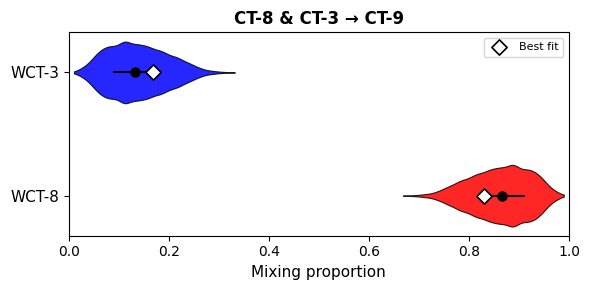

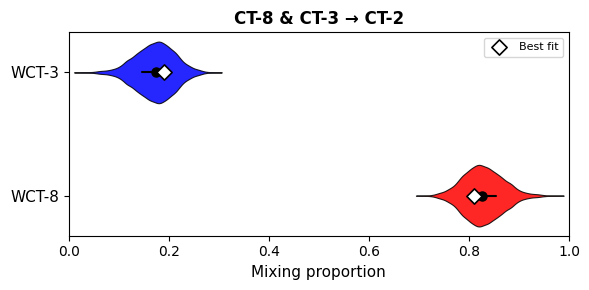

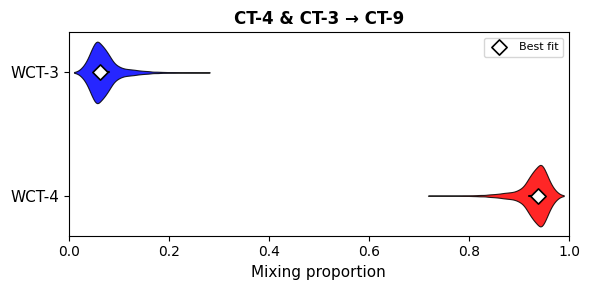

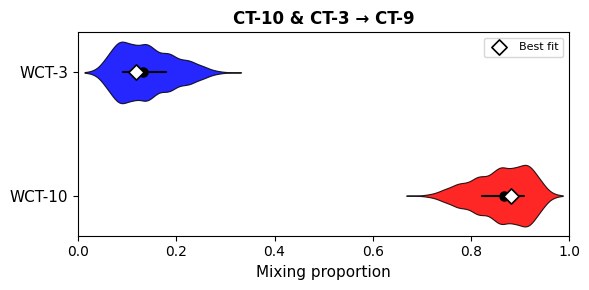

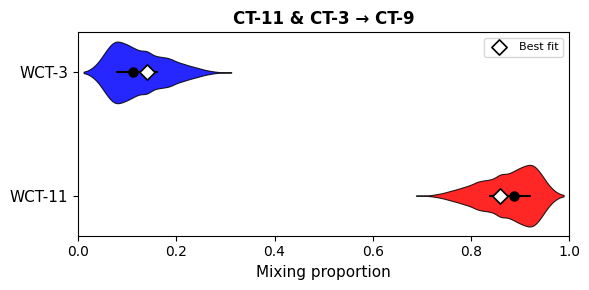

In [11]:
# ── CT-8/CT-3 and other parent scenarios ─────────────────────────────────────
wct_scenarios_83 = [
    ('ct9_83',  ['WCT-8','WCT-3'],  'CT-8 & CT-3 → CT-9',
     [0.830589798839197, 0.169410201160803], 'Figures/wct_violin_ct9_83.png'),
    ('ct2_83',  ['WCT-8','WCT-3'],  'CT-8 & CT-3 → CT-2',
     [0.809658442457024, 0.190341557542976], 'Figures/wct_violin_ct2_83.png'),
    ('ct9_43',  ['WCT-4','WCT-3'],  'CT-4 & CT-3 → CT-9',
     [0.937480464786899, 0.0625195352131011],'Figures/wct_violin_ct9_43.png'),
    ('ct9_103', ['WCT-10','WCT-3'], 'CT-10 & CT-3 → CT-9',
     [0.881432805539908, 0.118567194460092], 'Figures/wct_violin_ct9_103.png'),
    ('ct9_113', ['WCT-11','WCT-3'], 'CT-11 & CT-3 → CT-9',
     [0.860000109917762, 0.139999890082238], 'Figures/wct_violin_ct9_113.png'),
]
for key, labels, title, bf, path in wct_scenarios_83:
    plot_wct_violin(*wct[key], labels=labels, title=title, best_fit=bf, save_path=path)

## 9. Quartz fertility (Qa/Qb)

**a = CT-5 or CT-8 (numerator), b = CT-6 or CT-3 (denominator)**

Adjusted CT-3 source areas for CT-8/CT-3 scenarios:
- CT-9: A_CT3 = A(CT-9) − A(CT-8) ; CT-3 is contained within the CT-9 basin, so the unsampled coastal corridor area already includes CT-3; no separate addition needed
- CT-2: A_CT3 = A(CT-2) − A(CT-8) + A(CT-3) ; CT-3 lies outside the CT-2 basin boundary, so the corridor area plus the CT-3 drainage area must be added explicitly

In [12]:
# Adjusted CT-3 source areas for CT-8/CT-3 mixing scenarios
# CT-9: CT-3 drainage is fully contained within the CT-9 basin, so the
#        coastal contribution = total CT-9 area minus CT-8 area (no double-counting)
A_CT3_9 = A['CT-9'] - A['CT-8']  # km²

# CT-2: CT-3 drainage lies outside the CT-2 basin boundary, so it must be
#        added explicitly: unsampled corridor area + CT-3 drainage area itself
A_CT3_2 = A['CT-2'] - A['CT-8'] + A['CT-3']  # km²

# CT-5(a) + CT-6(b) scenarios
# CT-4: no flux ordering — erosion rate similar to CT-6, constraint is numerically unstable
Q_ct4,  _ = quartz_fertility(ER_ext['CT-5'], ER_ext['CT-6'], ER_ext['CT-4'],
                               A['CT-5'], A['CT-6'], A['CT-4'],
                               P['CT-5'], P['CT-6'], P['CT-4'])

Q_ct10, _ = quartz_fertility(CT5_10, CT6_10, CT10_f,
                               A['CT-5'], A['CT-6'], A['CT-10'],
                               P['CT-5'], P['CT-6'], P['CT-10'])

Q_ct11, _ = quartz_fertility(CT5_11, CT6_11, CT11_f,
                               A['CT-5'], A['CT-6'], A['CT-11'],
                               P['CT-5'], P['CT-6'], P['CT-11'])

Q_ct82, _ = quartz_fertility(CT5_8, CT6_8, CT8_f,
                               A['CT-5'], A['CT-6'], A['CT-8'],
                               P['CT-5'], P['CT-6'], P['CT-8'])

# CT-8(a) + CT-3(b) scenarios — adjusted CT-3 areas
Q_ct9,  _ = quartz_fertility(CT8_res, CT3_res, ER_ext['CT-9'],
                               A['CT-8'], A_CT3_9, A['CT-9'],
                               P['CT-8'], P['CT-3'], P['CT-9'])

Q_ct2,  _ = quartz_fertility(CT8_res, CT3_res, ER_ext['CT-2'],
                               A['CT-8'], A_CT3_2, A['CT-2'],
                               P['CT-8'], P['CT-3'], P['CT-2'])

print("Quartz Fertility Qa/Qb (external uncertainty)")
print(f"{'Scenario':<25} {'Linear med':>11} {'Linear IQR':>18} {'log10 med':>10} {'log10 IQR':>18} {'n':>8}")
print("-"*95)
qtz_results = [
    ('CT-5/CT-6 → CT-4',   Q_ct4),
    ('CT-5/CT-6 → CT-10',  Q_ct10),
    ('CT-5/CT-6 → CT-11',  Q_ct11),
    ('CT-5/CT-6 → CT-8.2', Q_ct82),
    ('CT-8/CT-3 → CT-9',   Q_ct9),
    ('CT-8/CT-3 → CT-2',   Q_ct2),
]
for label, Q in qtz_results:
    logQ = np.log10(Q)
    lmed = np.median(logQ)
    l25, l75 = np.percentile(logQ, [25, 75])
    q25, q75 = 10**l25, 10**l75  # back-transform IQR bounds
    print(f"{label:<25} {10**lmed:>11.4f} ({q25:.4f} - {q75:.4f})   {lmed:>10.4f} ({l25:.4f} - {l75:.4f})   {len(Q):>8}")

Quartz Fertility Qa/Qb (external uncertainty)
Scenario                   Linear med         Linear IQR  log10 med          log10 IQR        n
-----------------------------------------------------------------------------------------------
CT-5/CT-6 → CT-4               0.0127 (0.0062 - 0.0214)      -1.8952 (-2.2105 - -1.6695)      55523
CT-5/CT-6 → CT-10              3.4996 (2.6781 - 4.8205)       0.5440 (0.4278 - 0.6831)      99781
CT-5/CT-6 → CT-11              7.4759 (4.9496 - 13.1414)       0.8737 (0.6946 - 1.1186)      90945
CT-5/CT-6 → CT-8.2             4.8322 (3.4883 - 7.3302)       0.6841 (0.5426 - 0.8651)      98287
CT-8/CT-3 → CT-9               0.0295 (0.0227 - 0.0375)      -1.5300 (-1.6432 - -1.4262)      99985
CT-8/CT-3 → CT-2               0.0136 (0.0097 - 0.0180)      -1.8665 (-2.0124 - -1.7449)      99531


## 10. Zircon fertility (ZA/ZB)

**a = CT-5 or CT-8 or CT-4/CT-10/CT-11 (numerator), b = CT-6 or CT-3 (denominator)**

In [13]:
M = 10000  # Number of Monte Carlo samples for zircon fertility

# CT-5(a) + CT-6(b) — CT-4 uses unordered samples (same reason as quartz)
zr_ct4   = zircon_fertility(*wct['ct4'],  ER_ext['CT-5'][:M], ER_ext['CT-6'][:M], A['CT-5'], A['CT-6'], M)
zr_ct10  = zircon_fertility(*wct['ct10'], CT5_10[:M],          CT6_10[:M],          A['CT-5'], A['CT-6'], M)
zr_ct11  = zircon_fertility(*wct['ct11'], CT5_11[:M],          CT6_11[:M],          A['CT-5'], A['CT-6'], M)
zr_ct82  = zircon_fertility(*wct['ct82'], CT5_8[:M],           CT6_8[:M],           A['CT-5'], A['CT-6'], M)

# CT-8(a) + CT-3(b) — adjusted CT-3 areas
zr_ct9_83  = zircon_fertility(*wct['ct9_83'], CT8_res[:M], CT3_res[:M], A['CT-8'], A_CT3_9, M)
zr_ct2_83  = zircon_fertility(*wct['ct2_83'], CT8_res[:M], CT3_res[:M], A['CT-8'], A_CT3_2, M)

# CT-4(a) + CT-3(b) → CT-9 — raw CT-3 area
zr_ct9_43  = zircon_fertility(*wct['ct9_43'],  CT4_res[:M],  CT3_res[:M], A['CT-4'],  A['CT-3'], M)

# CT-10(a) + CT-3(b) → CT-9
zr_ct9_103 = zircon_fertility(*wct['ct9_103'], CT10_res[:M], CT3_res[:M], A['CT-10'], A['CT-3'], M)

# CT-11(a) + CT-3(b) → CT-9
zr_ct9_113 = zircon_fertility(*wct['ct9_113'], CT11_res[:M], CT3_res[:M], A['CT-11'], A['CT-3'], M)

print("Zircon Fertility ZA/ZB (external uncertainty)")
print(f"{'Scenario':<30} {'Linear med':>11} {'Linear IQR':>18} {'log10 med':>10} {'log10 IQR':>18}")
print("-"*93)
zrc_results = [
    ('ZCT-5/ZCT-6 → CT-4',   zr_ct4),
    ('ZCT-5/ZCT-6 → CT-10',  zr_ct10),
    ('ZCT-5/ZCT-6 → CT-11',  zr_ct11),
    ('ZCT-5/ZCT-6 → CT-8.2', zr_ct82),
    ('ZCT-8/ZCT-3 → CT-9',   zr_ct9_83),
    ('ZCT-8/ZCT-3 → CT-2',   zr_ct2_83),
    ('ZCT-4/ZCT-3 → CT-9',   zr_ct9_43),
    ('ZCT-10/ZCT-3 → CT-9',  zr_ct9_103),
    ('ZCT-11/ZCT-3 → CT-9',  zr_ct9_113),
]
for label, zr in zrc_results:
    r = zr['ZA_ZB']
    print(f"{label:<30} {r['median']:>11.4f} ({r['p25']:.4f} - {r['p75']:.4f})   {r['log10_median']:>10.4f} ({r['log10_p25']:.4f} - {r['log10_p75']:.4f})")

Zircon Fertility ZA/ZB (external uncertainty)
Scenario                        Linear med         Linear IQR  log10 med          log10 IQR
---------------------------------------------------------------------------------------------
ZCT-5/ZCT-6 → CT-4                  0.0487 (0.0345 - 0.0650)      -1.3126 (-1.4620 - -1.1868)
ZCT-5/ZCT-6 → CT-10                 0.2178 (0.1417 - 0.3179)      -0.6619 (-0.8485 - -0.4977)
ZCT-5/ZCT-6 → CT-11                 0.1045 (0.0618 - 0.1595)      -0.9809 (-1.2090 - -0.7973)
ZCT-5/ZCT-6 → CT-8.2                0.1355 (0.0916 - 0.1918)      -0.8682 (-1.0382 - -0.7171)
ZCT-8/ZCT-3 → CT-9                  0.1845 (0.1284 - 0.2816)      -0.7340 (-0.8914 - -0.5504)
ZCT-8/ZCT-3 → CT-2                  0.1090 (0.0900 - 0.1360)      -0.9628 (-1.0457 - -0.8666)
ZCT-4/ZCT-3 → CT-9                  0.5894 (0.4501 - 0.7642)      -0.2296 (-0.3467 - -0.1168)
ZCT-10/ZCT-3 → CT-9                 0.0309 (0.0216 - 0.0460)      -1.5095 (-1.6660 - -1.3376)
ZCT-11/ZCT-3 → C

## 11. Quartz fertility violin plots

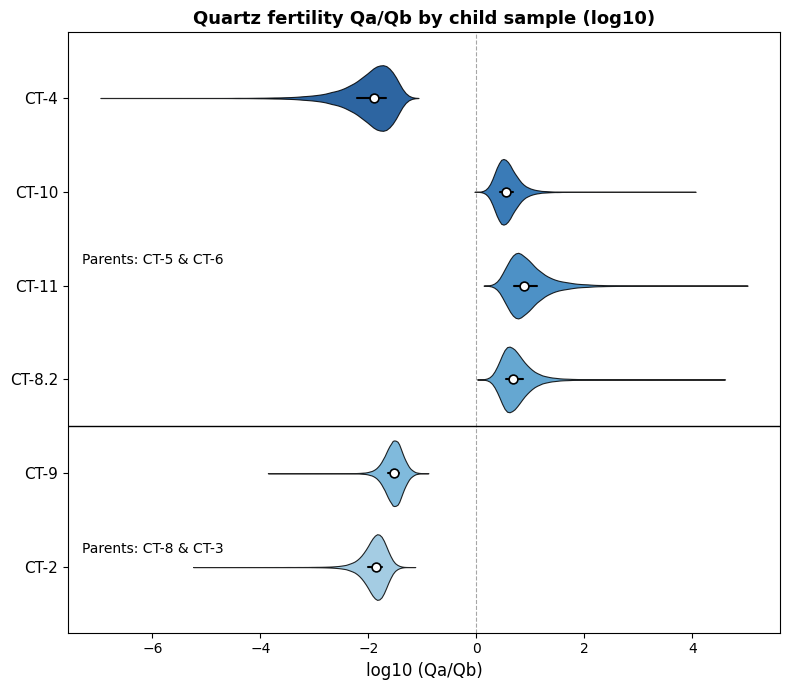

(<Figure size 800x700 with 1 Axes>,
 <Axes: title={'center': 'Quartz fertility Qa/Qb by child sample (log10)'}, xlabel='log10 (Qa/Qb)'>)

In [14]:
def fertility_violin(data_list, labels, title, xlabel,
                    separator_after=None, group_labels=None,
                    save_path=None, figsize=(8, 7)):
    """
    Horizontal violin plot for fertility ratio distributions (quartz or zircon).
    Plots log10 values with IQR bar and median dot overlaid.

    data_list      : list of 1D arrays (log10 values)
    labels         : y-axis label for each violin
    separator_after: draw horizontal separator line after this position (1-based)
    group_labels   : list of (text, y_axes_fraction) for group annotations
    """
    n = len(labels)
    cmap = plt.cm.Blues
    colors = [cmap(0.4 + 0.5*i/max(n-1,1)) for i in range(n)]

    fig, ax = plt.subplots(figsize=figsize)

    parts = ax.violinplot(data_list, positions=range(1, n+1), vert=False,
                          widths=0.7, showmeans=False, showextrema=False, showmedians=False)

    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i]); pc.set_edgecolor('black')
        pc.set_linewidth(0.8); pc.set_alpha(0.85)

    # IQR bar and median dot for each violin
    for i, (d, pos) in enumerate(zip(data_list, range(1, n+1))):
        ax.plot([np.percentile(d,25), np.percentile(d,75)], [pos, pos],
                color='black', linewidth=1.5, solid_capstyle='round', zorder=5)
        ax.scatter(np.median(d), pos, color='white', s=40,
                   edgecolor='black', linewidth=1.2, zorder=6)

    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)  # ratio = 1 reference

    if separator_after:
        ax.axhline(separator_after + 0.5, color='black', linewidth=1.0)

    if group_labels:
        for txt, y in group_labels:
            ax.text(0.02, y, txt, transform=ax.transAxes, fontsize=10, va='center')

    ax.set_yticks(range(1, n+1)); ax.set_yticklabels(labels, fontsize=11)
    ax.set_ylim(0.3, n+0.7)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', labelsize=10)
    #ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig, ax

# Log10 quartz fertility — reversed order so CT-4 at top
qtz_log_data = [np.log10(Q_ct2), np.log10(Q_ct9),
                np.log10(Q_ct82), np.log10(Q_ct11),
                np.log10(Q_ct10), np.log10(Q_ct4)]
qtz_labels   = ['CT-2','CT-9','CT-8.2','CT-11','CT-10','CT-4']

fertility_violin(qtz_log_data, qtz_labels,
    title='Quartz fertility Qa/Qb by child sample (log10)',
    xlabel='log10 (Qa/Qb)',
    separator_after=2,
    group_labels=[('Parents: CT-8 & CT-3', 0.14), ('Parents: CT-5 & CT-6', 0.62)],
    save_path='Figures/violin_qfertility_log10.png')

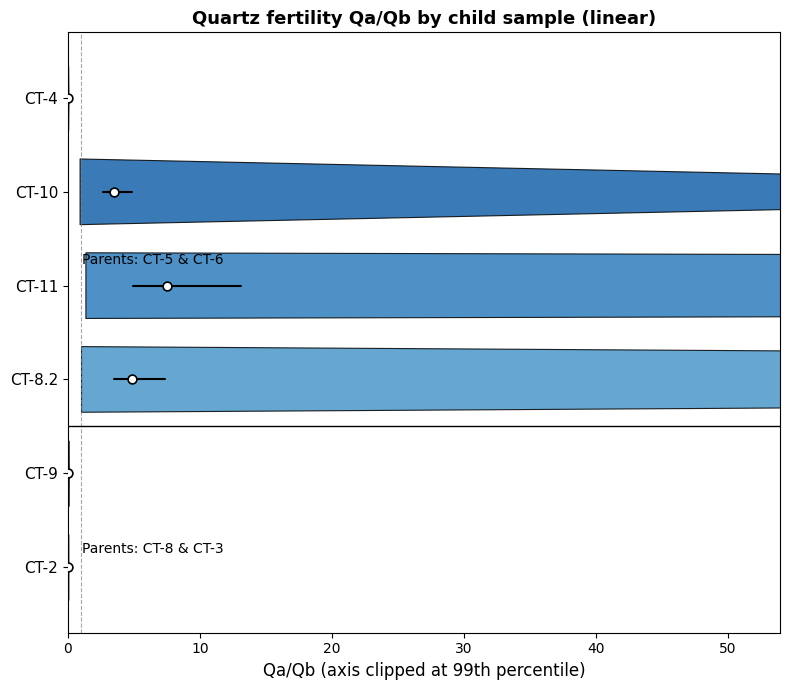

In [15]:
# Linear quartz fertility violin — x-axis clipped at 99th percentile for display
# Reported medians are back-transformed from log10 space (not affected by clipping)
qtz_lin_data = [Q_ct2, Q_ct9, Q_ct82, Q_ct11, Q_ct10, Q_ct4]

# Clip x-axis to 99th percentile across all scenarios for a clean display
clip_max = np.percentile(np.concatenate(qtz_lin_data), 99)

n = len(qtz_labels)
cmap = plt.cm.Blues
colors = [cmap(0.4 + 0.5*i/max(n-1,1)) for i in range(n)]

fig, ax = plt.subplots(figsize=(8,7))
parts = ax.violinplot(qtz_lin_data, positions=range(1,n+1), vert=False,
                      widths=0.7, showmeans=False, showextrema=False, showmedians=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i]); pc.set_edgecolor('black')
    pc.set_linewidth(0.8); pc.set_alpha(0.85)

for i, (d, pos) in enumerate(zip(qtz_lin_data, range(1,n+1))):
    ax.plot([np.percentile(d,25), np.percentile(d,75)], [pos,pos],
            color='black', linewidth=1.5, solid_capstyle='round', zorder=5)
    ax.scatter(np.median(d), pos, color='white', s=40,
               edgecolor='black', linewidth=1.2, zorder=6)

ax.axvline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)  # ratio = 1
ax.axhline(2.5, color='black', linewidth=1.0)
ax.set_xlim(0, clip_max)  # clip tail for display clarity
ax.set_yticks(range(1,n+1)); ax.set_yticklabels(qtz_labels, fontsize=11)
ax.set_ylim(0.3, n+0.7)
ax.set_xlabel('Qa/Qb (axis clipped at 99th percentile)', fontsize=12)
ax.set_title('Quartz fertility Qa/Qb by child sample (linear)', fontsize=13, fontweight='bold')
ax.text(0.02, 0.14, 'Parents: CT-8 & CT-3', transform=ax.transAxes, fontsize=10, va='center')
ax.text(0.02, 0.62, 'Parents: CT-5 & CT-6', transform=ax.transAxes, fontsize=10, va='center')
#ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('Figures/violin_qfertility_linear.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Zircon fertility violin plots

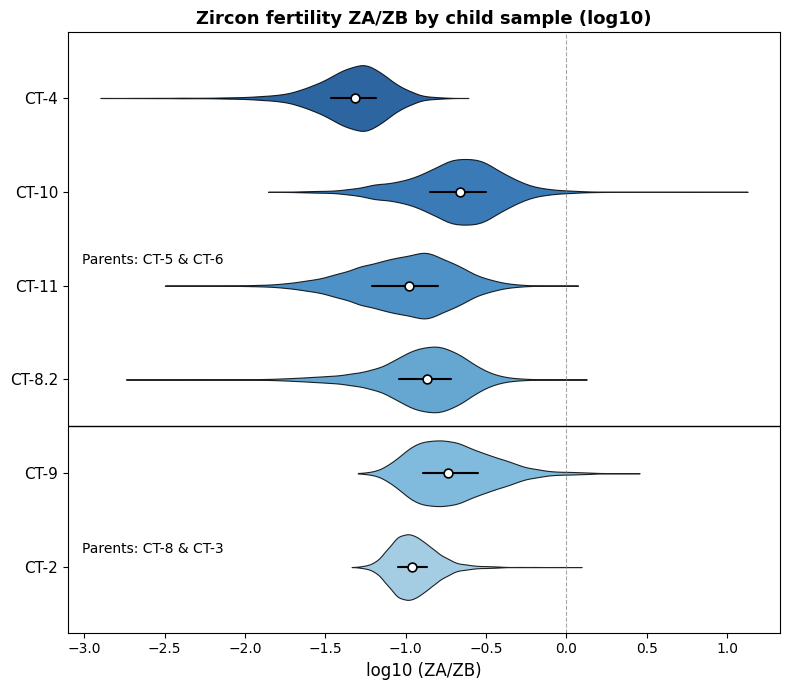

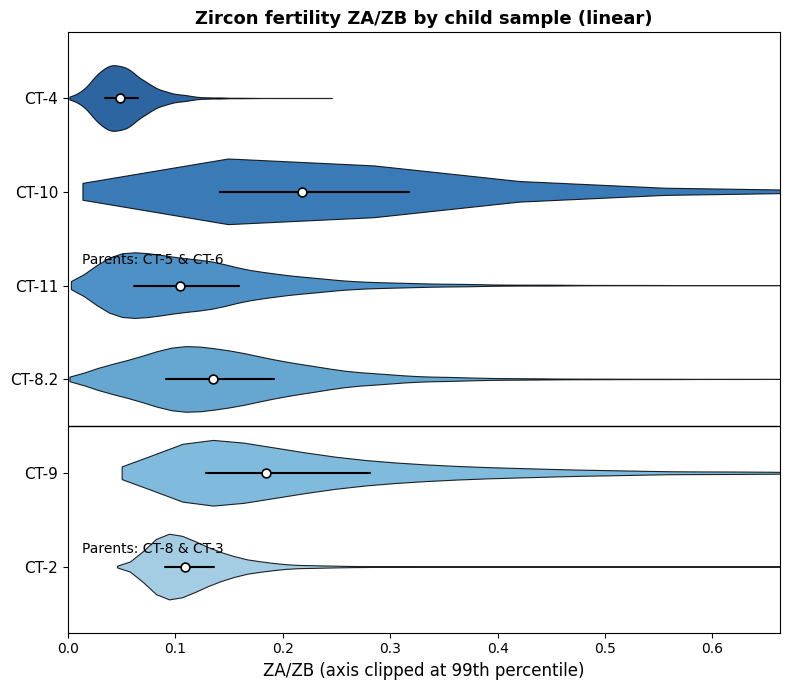

In [16]:
# Reversed order so CT-4 at top
zrc_log_data = [zr_ct2_83['ZA_ZB']['log10_samples'], zr_ct9_83['ZA_ZB']['log10_samples'],
                zr_ct82['ZA_ZB']['log10_samples'],    zr_ct11['ZA_ZB']['log10_samples'],
                zr_ct10['ZA_ZB']['log10_samples'],    zr_ct4['ZA_ZB']['log10_samples']]
zrc_lin_data = [zr_ct2_83['ZA_ZB']['samples'], zr_ct9_83['ZA_ZB']['samples'],
                zr_ct82['ZA_ZB']['samples'],   zr_ct11['ZA_ZB']['samples'],
                zr_ct10['ZA_ZB']['samples'],   zr_ct4['ZA_ZB']['samples']]
zrc_labels   = ['CT-2','CT-9','CT-8.2','CT-11','CT-10','CT-4']
sep = 2
gl = [('Parents: CT-8 & CT-3', 0.14), ('Parents: CT-5 & CT-6', 0.62)]

# Log10 zircon violin
fertility_violin(zrc_log_data, zrc_labels,
    title='Zircon fertility ZA/ZB by child sample (log10)',
    xlabel='log10 (ZA/ZB)',
    separator_after=sep, group_labels=gl,
    save_path='Figures/violin_zfertility_log10.png')

# Linear zircon violin (clipped at 99th percentile)
clip_max_z = np.percentile(np.concatenate(zrc_lin_data), 99)

fig, ax = plt.subplots(figsize=(8,7))
parts = ax.violinplot(zrc_lin_data, positions=range(1,n+1), vert=False,
                      widths=0.7, showmeans=False, showextrema=False, showmedians=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i]); pc.set_edgecolor('black')
    pc.set_linewidth(0.8); pc.set_alpha(0.85)
for i, (d, pos) in enumerate(zip(zrc_lin_data, range(1,n+1))):
    ax.plot([np.percentile(d,25), np.percentile(d,75)], [pos,pos],
            color='black', linewidth=1.5, solid_capstyle='round', zorder=5)
    ax.scatter(np.median(d), pos, color='white', s=40,
               edgecolor='black', linewidth=1.2, zorder=6)
ax.axvline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axhline(2.5, color='black', linewidth=1.0)
ax.set_xlim(0, clip_max_z)
ax.set_yticks(range(1,n+1)); ax.set_yticklabels(zrc_labels, fontsize=11)
ax.set_ylim(0.3, n+0.7)
ax.set_xlabel('ZA/ZB (axis clipped at 99th percentile)', fontsize=12)
ax.set_title('Zircon fertility ZA/ZB by child sample (linear)', fontsize=13, fontweight='bold')
ax.text(0.02, 0.14, 'Parents: CT-8 & CT-3', transform=ax.transAxes, fontsize=10, va='center')
ax.text(0.02, 0.62, 'Parents: CT-5 & CT-6', transform=ax.transAxes, fontsize=10, va='center')
#ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('Figures/violin_zfertility_linear.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Distribution plots

Individual 4-panel plots per scenario (quartz linear, quartz log10, zircon linear, zircon log10).
Combined comparison plots at the end for each parent group.

In [17]:
def plot_single_scenario(Q, zr, label, save_path=None):
    """
    4 individual figures per scenario (one per panel), each saved separately.
    Quartz and zircon linear axes clipped at 99th percentile for display.
    Reported medians are back-transformed from log10 space.

    Q         : quartz Qa/Qb array
    zr        : zircon results dict from zircon_fertility()
    save_path : base path — suffix (_qlin, _qlog, _zlin, _zlog) added per figure
    """
    Z    = zr['ZA_ZB']['samples']
    logQ = np.log10(Q)
    logZ = zr['ZA_ZB']['log10_samples']
    q_clip = np.percentile(Q, 99)
    z_clip = np.percentile(Z, 99)

    base = save_path.replace('.png', '') if save_path else None

    # ── Quartz linear ──────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.hist(Q[Q <= q_clip], bins=100, color='steelblue', alpha=0.8, density=True, edgecolor='none')
    ax.axvline(10**np.median(logQ), color='black', linewidth=1.2, linestyle='--',
               label=f'Median: {10**np.median(logQ):.2f}')
    ax.set_xlabel('Qa/Qb (clipped at 99th pct)'); ax.set_ylabel('Density')
    ax.set_title(f'{label} — Quartz (linear)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    if base: plt.savefig(f'{base}_qlin.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ── Quartz log10 ──────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.hist(logQ, bins=100, color='steelblue', alpha=0.8, density=True, edgecolor='none')
    ax.axvline(np.median(logQ), color='black', linewidth=1.2, linestyle='--',
               label=f'log10 median: {np.median(logQ):.2f}')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_xlabel('log10(Qa/Qb)'); ax.set_ylabel('Density')
    ax.set_title(f'{label} — Quartz (log10)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    if base: plt.savefig(f'{base}_qlog.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ── Zircon linear ─────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.hist(Z[Z <= z_clip], bins=100, color='darkorange', alpha=0.8, density=True, edgecolor='none')
    ax.axvline(10**np.median(logZ), color='black', linewidth=1.2, linestyle='--',
               label=f'Median: {10**np.median(logZ):.2f}')
    ax.set_xlabel('ZA/ZB (clipped at 99th pct)'); ax.set_ylabel('Density')
    ax.set_title(f'{label} — Zircon (linear)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    if base: plt.savefig(f'{base}_zlin.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ── Zircon log10 ──────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.hist(logZ, bins=100, color='darkorange', alpha=0.8, density=True, edgecolor='none')
    ax.axvline(np.median(logZ), color='black', linewidth=1.2, linestyle='--',
               label=f'log10 median: {np.median(logZ):.2f}')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_xlabel('log10(ZA/ZB)'); ax.set_ylabel('Density')
    ax.set_title(f'{label} — Zircon (log10)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    if base: plt.savefig(f'{base}_zlog.png', dpi=300, bbox_inches='tight')
    plt.show()

print("Plotting individual scenario distributions...")

Plotting individual scenario distributions...


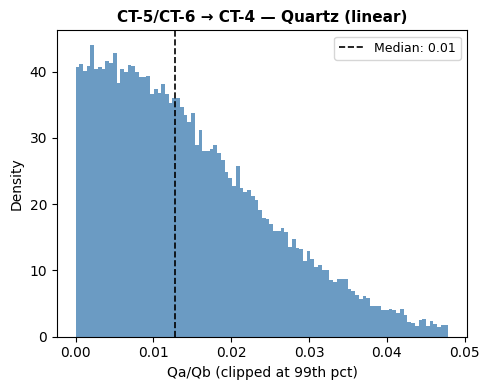

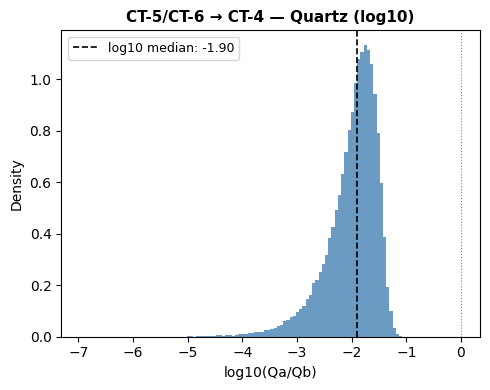

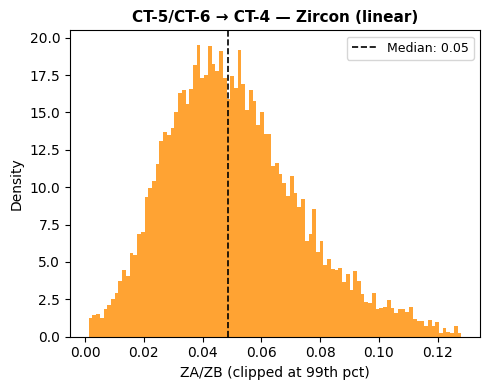

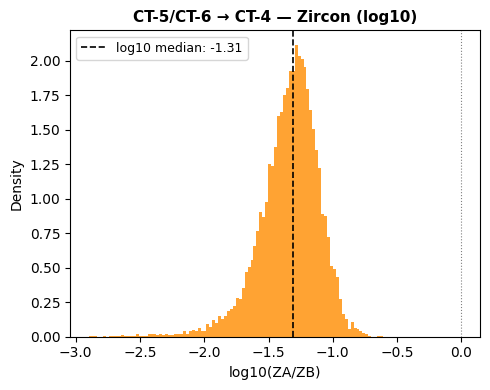

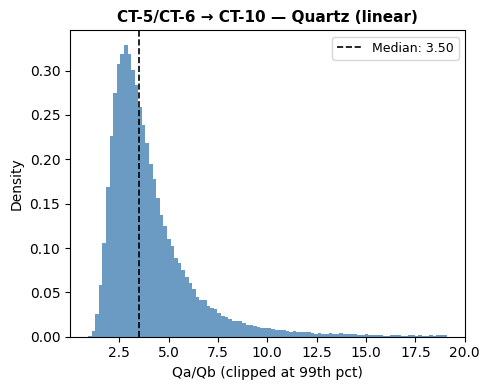

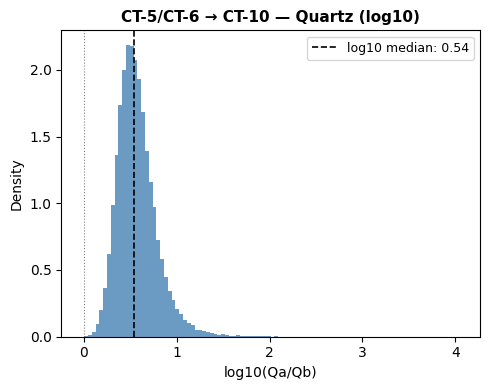

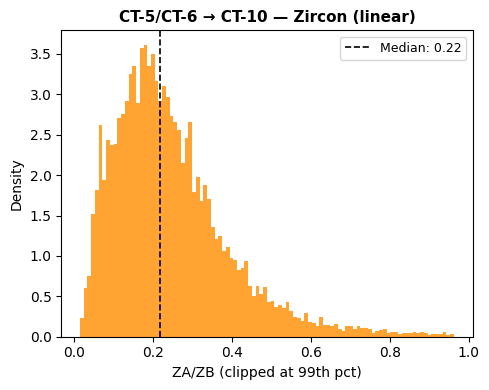

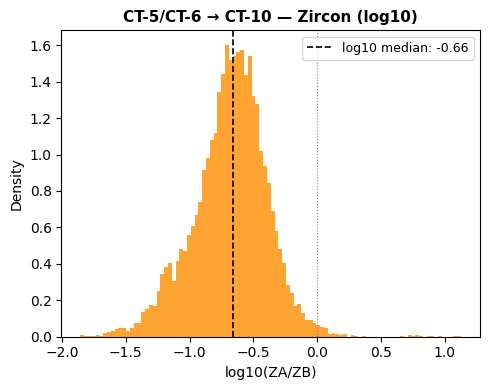

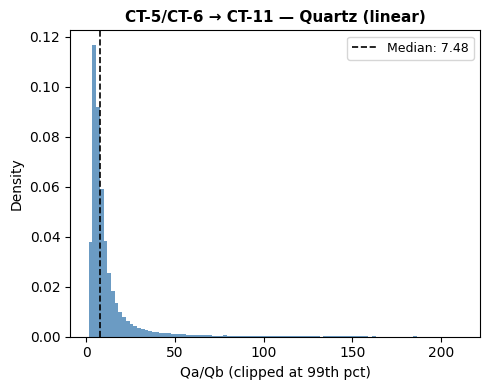

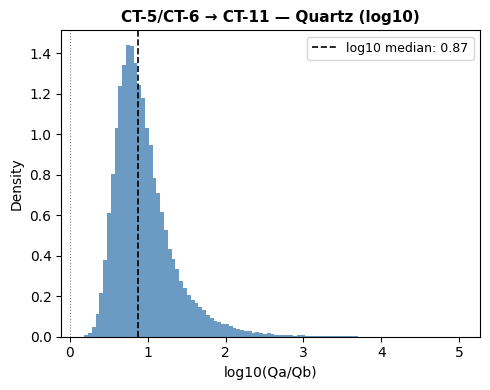

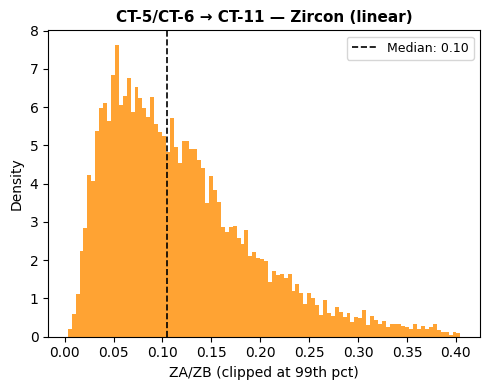

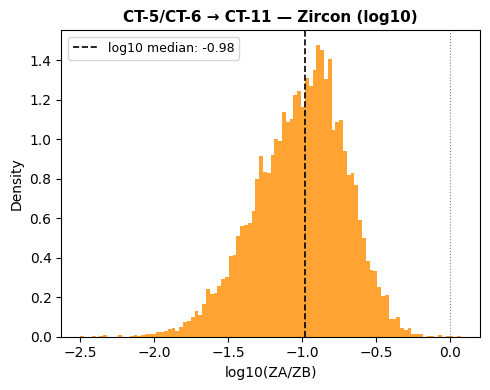

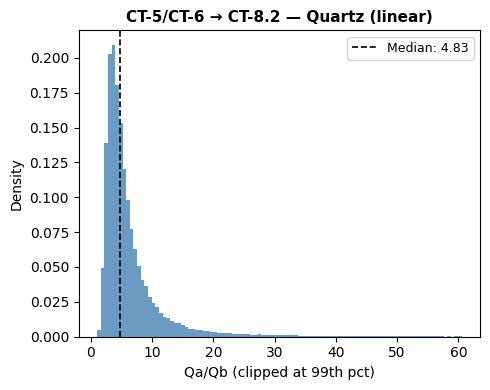

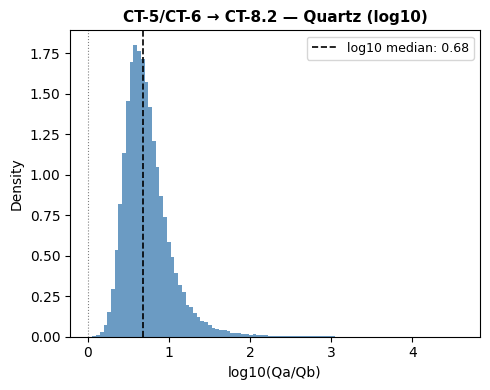

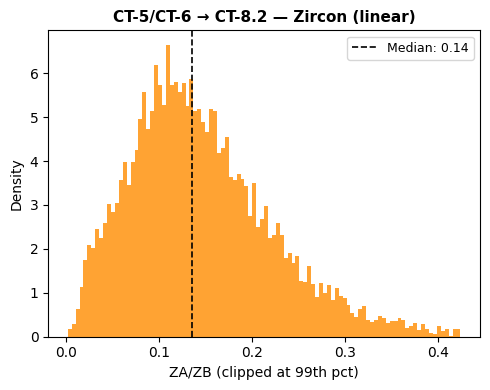

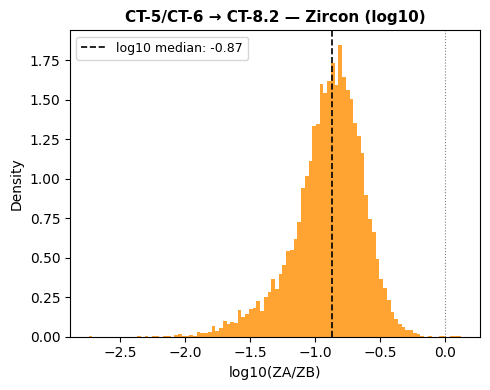

In [18]:
# Individual plots — CT-5/CT-6 parent scenarios
for Q, zr, label, path in [
    (Q_ct4,  zr_ct4,  'CT-5/CT-6 → CT-4',   'Figures/dist_ct4.png'),
    (Q_ct10, zr_ct10, 'CT-5/CT-6 → CT-10',  'Figures/dist_ct10.png'),
    (Q_ct11, zr_ct11, 'CT-5/CT-6 → CT-11',  'Figures/dist_ct11.png'),
    (Q_ct82, zr_ct82, 'CT-5/CT-6 → CT-8.2', 'Figures/dist_ct82.png'),
]:
    plot_single_scenario(Q, zr, label, save_path=path)

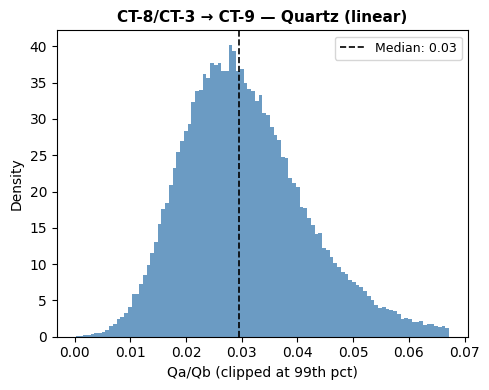

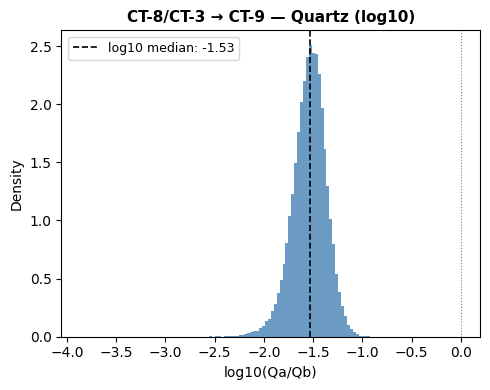

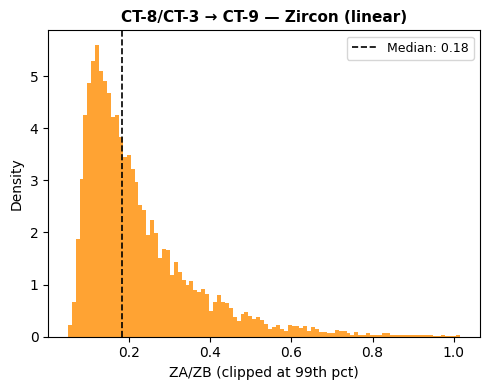

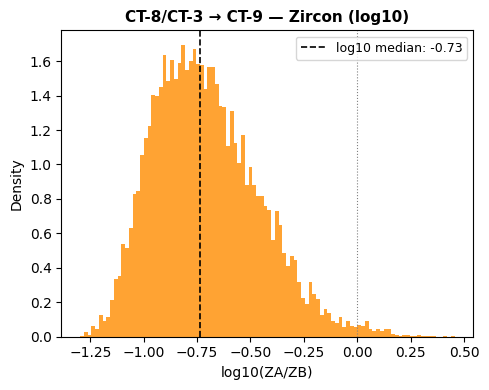

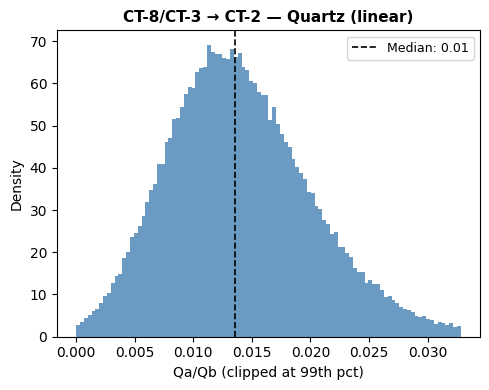

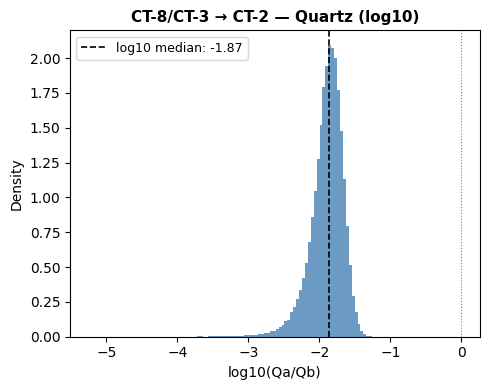

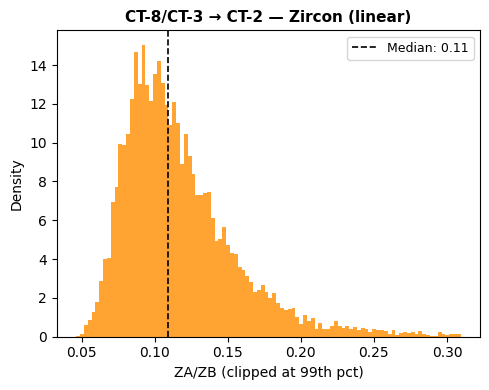

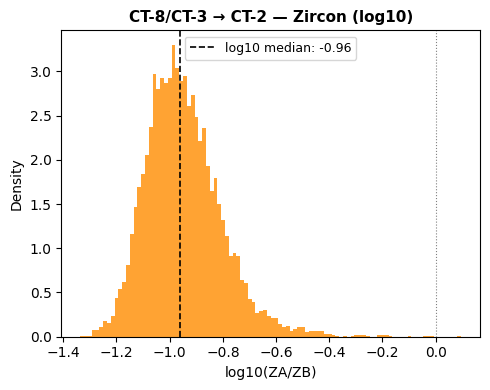

In [19]:
# Individual plots — CT-8/CT-3 parent scenarios
for Q, zr, label, path in [
    (Q_ct9, zr_ct9_83, 'CT-8/CT-3 → CT-9', 'Figures/dist_ct9_83.png'),
    (Q_ct2, zr_ct2_83, 'CT-8/CT-3 → CT-2', 'Figures/dist_ct2_83.png'),
]:
    plot_single_scenario(Q, zr, label, save_path=path)

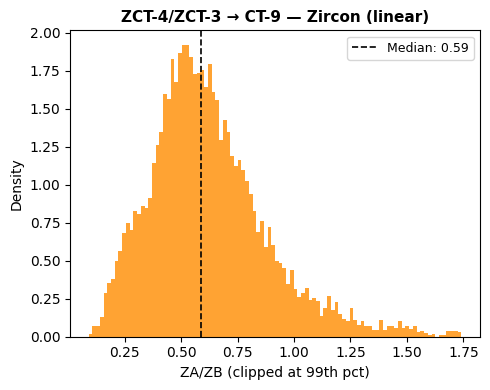

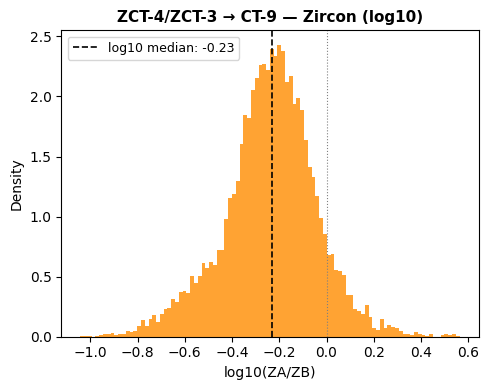

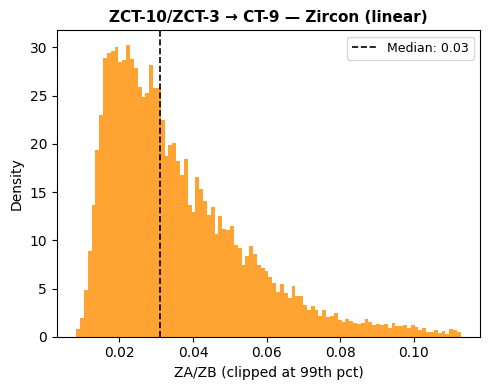

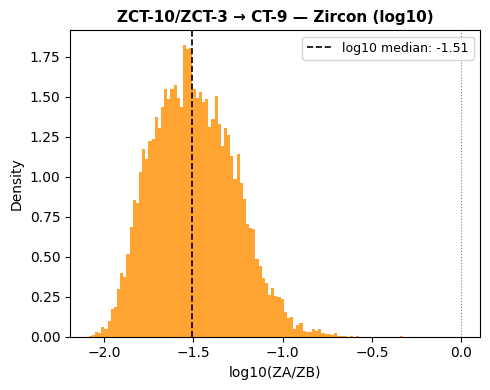

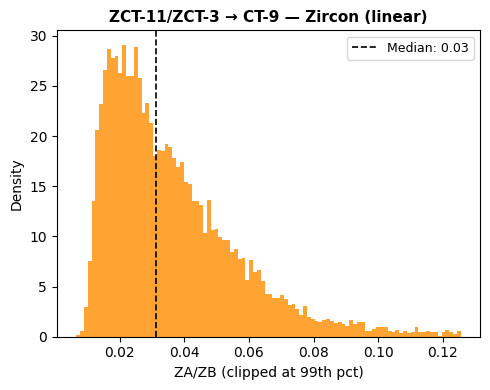

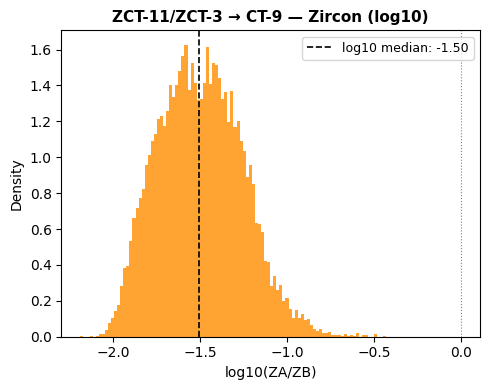

In [20]:
# Individual plots — additional zircon-only scenarios (no quartz equivalent)
for zr, label, base_path in [
    (zr_ct9_43,  'ZCT-4/ZCT-3 → CT-9',  'Figures/dist_z_ct9_43'),
    (zr_ct9_103, 'ZCT-10/ZCT-3 → CT-9', 'Figures/dist_z_ct9_103'),
    (zr_ct9_113, 'ZCT-11/ZCT-3 → CT-9', 'Figures/dist_z_ct9_113'),
]:
    Z    = zr['ZA_ZB']['samples']
    logZ = zr['ZA_ZB']['log10_samples']
    z_clip = np.percentile(Z, 99)

    # Zircon linear
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.hist(Z[Z <= z_clip], bins=100, color='darkorange', alpha=0.8, density=True, edgecolor='none')
    ax.axvline(10**np.median(logZ), color='black', linewidth=1.2, linestyle='--',
               label=f'Median: {10**np.median(logZ):.2f}')
    ax.set_xlabel('ZA/ZB (clipped at 99th pct)'); ax.set_ylabel('Density')
    ax.set_title(f'{label} — Zircon (linear)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{base_path}_zlin.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Zircon log10
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.hist(logZ, bins=100, color='darkorange', alpha=0.8, density=True, edgecolor='none')
    ax.axvline(np.median(logZ), color='black', linewidth=1.2, linestyle='--',
               label=f'log10 median: {np.median(logZ):.2f}')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_xlabel('log10(ZA/ZB)'); ax.set_ylabel('Density')
    ax.set_title(f'{label} — Zircon (log10)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{base_path}_zlog.png', dpi=300, bbox_inches='tight')
    plt.show()

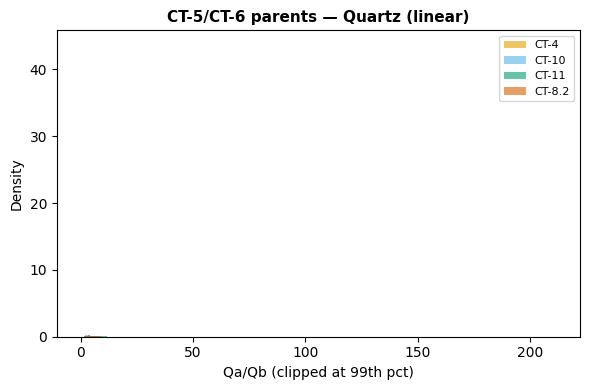

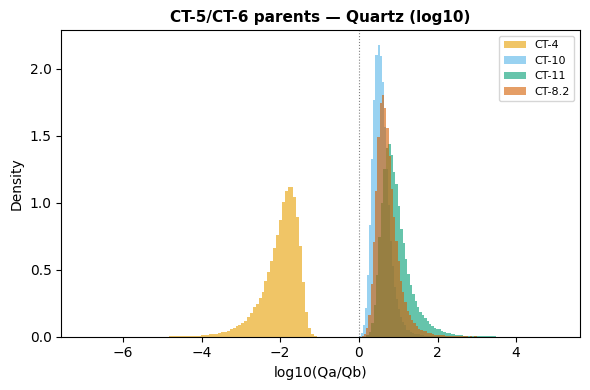

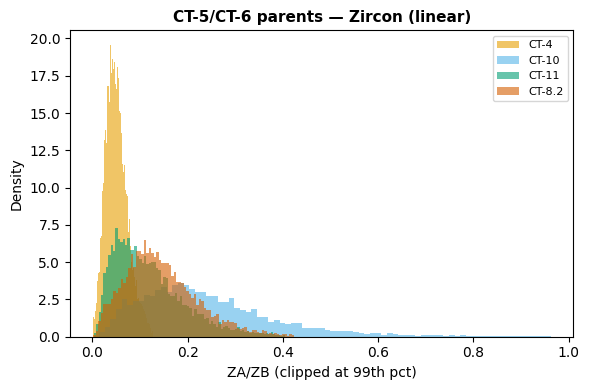

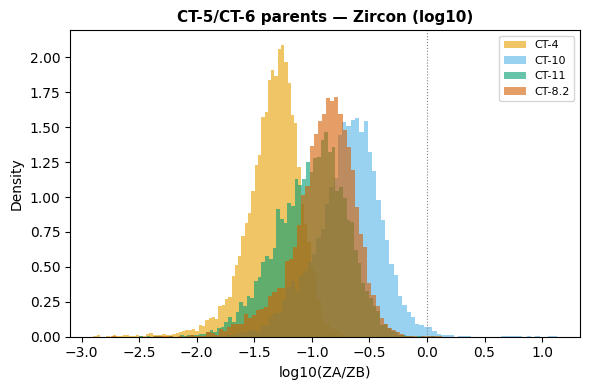

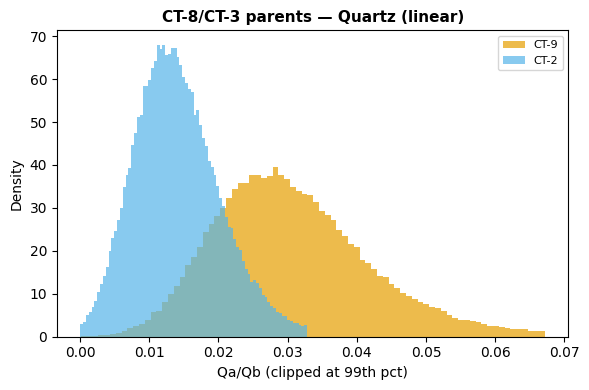

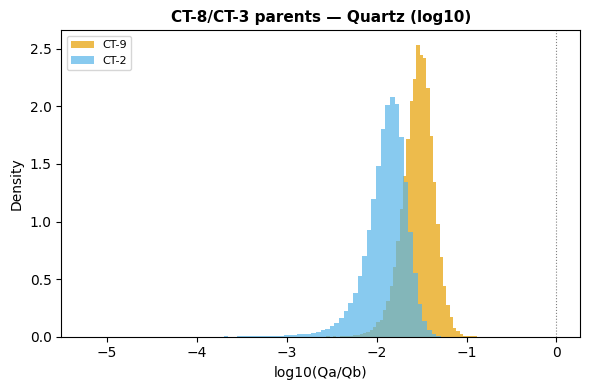

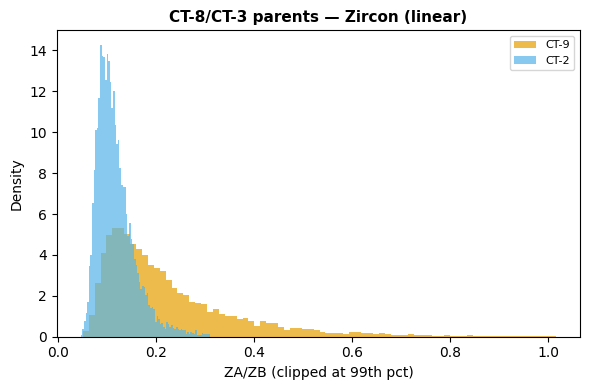

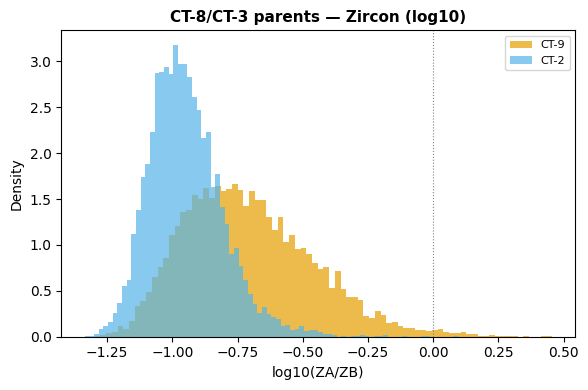

In [21]:
# ── Combined comparison plots ─────────────────────────────────────────────────
# Colorblind-friendly palette (Wong 2011): orange, sky blue, bluish green, vermillion
CB_COLORS = ['#E69F00', '#56B4E9', '#009E73', '#D55E00']

# Panel definitions: (xlabel, title, data_fn, log_ref_line, savename_suffix)
panels_56 = [
    ('Qa/Qb (clipped at 99th pct)', 'Quartz (linear)',  lambda Q,zr,qc,zc: (Q[Q<=qc], False),  'qlin'),
    ('log10(Qa/Qb)',                 'Quartz (log10)',   lambda Q,zr,qc,zc: (np.log10(Q), True), 'qlog'),
    ('ZA/ZB (clipped at 99th pct)', 'Zircon (linear)',  lambda Q,zr,qc,zc: (zr['ZA_ZB']['samples'][zr['ZA_ZB']['samples']<=zc], False), 'zlin'),
    ('log10(ZA/ZB)',                 'Zircon (log10)',   lambda Q,zr,qc,zc: (zr['ZA_ZB']['log10_samples'], True), 'zlog'),
]

# CT-5/CT-6 group — one figure per panel type
for xlabel, title, data_fn, suffix in panels_56:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_title(f'CT-5/CT-6 parents — {title}', fontsize=11, fontweight='bold')
    for i, (Q, zr, lbl) in enumerate(zip(
        [Q_ct4, Q_ct10, Q_ct11, Q_ct82],
        [zr_ct4, zr_ct10, zr_ct11, zr_ct82],
        ['CT-4', 'CT-10', 'CT-11', 'CT-8.2']
    )):
        q_clip = np.percentile(Q, 99)
        z_clip = np.percentile(zr['ZA_ZB']['samples'], 99)
        d, add_ref = data_fn(Q, zr, q_clip, z_clip)
        ax.hist(d, bins=80, alpha=0.6, color=CB_COLORS[i], density=True, label=lbl, edgecolor='none')
    if add_ref:
        ax.axvline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_xlabel(xlabel); ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    #ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'Figures/dist_combined_ct5_ct6_{suffix}.png', dpi=300, bbox_inches='tight')
    plt.show()

# CT-8/CT-3 group — one figure per panel type
for xlabel, title, data_fn, suffix in panels_56:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_title(f'CT-8/CT-3 parents — {title}', fontsize=11, fontweight='bold')
    for i, (Q, zr, lbl) in enumerate(zip(
        [Q_ct9, Q_ct2],
        [zr_ct9_83, zr_ct2_83],
        ['CT-9', 'CT-2']
    )):
        q_clip = np.percentile(Q, 99)
        z_clip = np.percentile(zr['ZA_ZB']['samples'], 99)
        d, add_ref = data_fn(Q, zr, q_clip, z_clip)
        ax.hist(d, bins=80, alpha=0.7, color=CB_COLORS[i], density=True, label=lbl, edgecolor='none')
    if add_ref:
        ax.axvline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_xlabel(xlabel); ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    #ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'Figures/dist_combined_ct8_ct3_{suffix}.png', dpi=300, bbox_inches='tight')
    plt.show()

## 14. Results summary

In [22]:
print("="*115)
print("SUMMARY — FORWARD RATIOS: Quartz (Qa/Qb) and Zircon (ZA/ZB) — CT-5/CT-8 numerator, CT-6/CT-3 denominator")
print("="*115)
print(f"{'Scenario':<28} {'Q linear med':>13} {'Q linear IQR':>20} {'Q log10 med':>12} {'Q log10 IQR':>20} {'Z linear med':>13} {'Z linear IQR':>20} {'Z log10 med':>12} {'Z log10 IQR':>20}")
print("-"*165)

main = [
    ('CT-5/CT-6 → CT-4',   Q_ct4,  zr_ct4),
    ('CT-5/CT-6 → CT-10',  Q_ct10, zr_ct10),
    ('CT-5/CT-6 → CT-11',  Q_ct11, zr_ct11),
    ('CT-5/CT-6 → CT-8.2', Q_ct82, zr_ct82),
    ('CT-8/CT-3 → CT-9',   Q_ct9,  zr_ct9_83),
    ('CT-8/CT-3 → CT-2',   Q_ct2,  zr_ct2_83),
]
for label, Q, zr in main:
    logQ = np.log10(Q)
    ql, qm, qh = np.percentile(logQ, [25, 50, 75])
    q25, q75 = 10**ql, 10**qh  # back-transformed IQR
    r = zr['ZA_ZB']
    print(f"{label:<28} {10**qm:>13.4f} ({q25:.4f} - {q75:.4f})   {qm:>12.4f} ({ql:.4f} - {qh:.4f})   {r['median']:>13.4f} ({r['p25']:.4f} - {r['p75']:.4f})   {r['log10_median']:>12.4f} ({r['log10_p25']:.4f} - {r['log10_p75']:.4f})")

print()
print("Additional zircon-only scenarios (ZA/ZB):")
print(f"{'Scenario':<28} {'Z linear med':>13} {'Z linear IQR':>20} {'Z log10 med':>12} {'Z log10 IQR':>20}")
print("-"*90)
for label, zr in [('CT-4/CT-3 → CT-9',  zr_ct9_43),
                   ('CT-10/CT-3 → CT-9', zr_ct9_103),
                   ('CT-11/CT-3 → CT-9', zr_ct9_113)]:
    r = zr['ZA_ZB']
    print(f"{label:<28} {r['median']:>13.4f} ({r['p25']:.4f} - {r['p75']:.4f})   {r['log10_median']:>12.4f} ({r['log10_p25']:.4f} - {r['log10_p75']:.4f})")

# ── Inverse ratios ─────────────────────────────────────────────────────────────
print()
print("="*115)
print("SUMMARY — INVERSE RATIOS: Quartz (Qb/Qa) and Zircon (ZB/ZA) — CT-6/CT-3 numerator, CT-5/CT-8 denominator")
print("Note: log10(inverse) = -log10(forward); linear inverse = 1 / linear forward")
print("="*115)
print(f"{'Scenario':<28} {'Q linear med':>13} {'Q linear IQR':>20} {'Q log10 med':>12} {'Q log10 IQR':>20} {'Z linear med':>13} {'Z linear IQR':>20} {'Z log10 med':>12} {'Z log10 IQR':>20}")
print("-"*165)

for label, Q, zr in main:
    logQ = np.log10(Q)
    ql, qm, qh = np.percentile(logQ, [25, 50, 75])
    # Inverse quartz: negate log10, swap IQR bounds; back-transform to linear
    qi_med = -qm; qi_lo = -qh; qi_hi = -ql
    r = zr['ZB_ZA']
    inv_label = label.replace('CT-5/CT-6', 'CT-6/CT-5').replace('CT-8/CT-3', 'CT-3/CT-8')
    print(f"{inv_label:<28} {10**qi_med:>13.4f} ({10**qi_lo:.4f} - {10**qi_hi:.4f})   {qi_med:>12.4f} ({qi_lo:.4f} - {qi_hi:.4f})   {r['median']:>13.4f} ({r['p25']:.4f} - {r['p75']:.4f})   {r['log10_median']:>12.4f} ({r['log10_p25']:.4f} - {r['log10_p75']:.4f})")

print()
print("Additional zircon-only inverse scenarios (ZB/ZA):")
print(f"{'Scenario':<28} {'Z linear med':>13} {'Z linear IQR':>20} {'Z log10 med':>12} {'Z log10 IQR':>20}")
print("-"*90)
for label, zr in [('CT-3/CT-4 → CT-9',  zr_ct9_43),
                   ('CT-3/CT-10 → CT-9', zr_ct9_103),
                   ('CT-3/CT-11 → CT-9', zr_ct9_113)]:
    r = zr['ZB_ZA']
    print(f"{label:<28} {r['median']:>13.4f} ({r['p25']:.4f} - {r['p75']:.4f})   {r['log10_median']:>12.4f} ({r['log10_p25']:.4f} - {r['log10_p75']:.4f})")

SUMMARY — FORWARD RATIOS: Quartz (Qa/Qb) and Zircon (ZA/ZB) — CT-5/CT-8 numerator, CT-6/CT-3 denominator
Scenario                      Q linear med         Q linear IQR  Q log10 med          Q log10 IQR  Z linear med         Z linear IQR  Z log10 med          Z log10 IQR
---------------------------------------------------------------------------------------------------------------------------------------------------------------------
CT-5/CT-6 → CT-4                    0.0127 (0.0062 - 0.0214)        -1.8952 (-2.2105 - -1.6695)          0.0487 (0.0345 - 0.0650)        -1.3126 (-1.4620 - -1.1868)
CT-5/CT-6 → CT-10                   3.4996 (2.6781 - 4.8205)         0.5440 (0.4278 - 0.6831)          0.2178 (0.1417 - 0.3179)        -0.6619 (-0.8485 - -0.4977)
CT-5/CT-6 → CT-11                   7.4759 (4.9496 - 13.1414)         0.8737 (0.6946 - 1.1186)          0.1045 (0.0618 - 0.1595)        -0.9809 (-1.2090 - -0.7973)
CT-5/CT-6 → CT-8.2                  4.8322 (3.4883 - 7.3302)         0